# Réf.: https://www.youtube.com/watch?v=VP_ewUk9Fpc&list=PL049bGjkT7dIARLPrxvA4-tbEcg6k0UDX&index=25

In [337]:
import numpy as np


In [338]:
def erreur(x, w, y):
  y_model = model(x, w)
  distance = (y - y_model) **2
  return np.sum(distance)


In [339]:
def erreur(X, Y, W, B):

  M = np.dot(X, W)

  P = M + B

  L = np.mean((Y-P) ** 2)

  return L # (Loss)


In [340]:
X = np.array([
    [2, 3, -2],
    [4, 5, -1],
    [-5, 2, 3],
    [0, 5, 4]
])


In [341]:
X.shape


(4, 3)

In [342]:
Y = np.array([
    [2],
    [5],
    [6],
    [3]
])


In [343]:
Y.shape


(4, 1)

In [344]:
W = np.array([
    [0.02],
    [18],
    [15]
])


In [345]:
W.shape


(3, 1)

In [346]:
B = 0.5


In [347]:
erreur(X, Y, W, B)


np.float64(8232.7495)

In [348]:
params = {"W": W, "B": B}


In [349]:
params


{'W': array([[ 0.02],
        [18.  ],
        [15.  ]]),
 'B': 0.5}

In [350]:
params['W']


array([[ 0.02],
       [18.  ],
       [15.  ]])

In [351]:
params['B']


0.5

In [352]:
def erreur(X, Y, params):

  info = {}

  M = np.dot(X, params['W'])

  P = M + params['B']

  L = np.mean((Y-P) ** 2) # Loss

  info['M'] = M
  info['P'] = P

  info['X'] = X
  info['Y'] = Y



  return L, info


In [353]:
loss, info = erreur(X, Y, params)


In [354]:
loss


np.float64(8232.7495)

In [355]:
info


{'M': array([[ 24.04],
        [ 75.08],
        [ 80.9 ],
        [150.  ]]),
 'P': array([[ 24.54],
        [ 75.58],
        [ 81.4 ],
        [150.5 ]]),
 'X': array([[ 2,  3, -2],
        [ 4,  5, -1],
        [-5,  2,  3],
        [ 0,  5,  4]]),
 'Y': array([[2],
        [5],
        [6],
        [3]])}

In [356]:
W.shape


(3, 1)

In [357]:
W


array([[ 0.02],
       [18.  ],
       [15.  ]])

In [358]:
B


0.5

In [359]:
def gradient(info, params):
  grads = {}

  dL_dP = -2 * (info['Y'] - info['P']) # (4, 1)

  dP_dM = 1

  dM_dW = info['X'].T #(3, 4)


  dL_dW = np.dot(dM_dW, dL_dP) * dP_dM   # (4, 1) * (3, 4)  → (3, 4) (4, 1)
  grads['W'] = dL_dW

  # print (f'{dL_dP = }', f'{dP_dM = }', f'{dM_dW = }', sep='\n')

  dP_dB = 1

  dL_dB = dL_dP * dP_dB #(4, 1) * 1

  dL_dB = np.sum(dL_dB)

  grads['B'] = dL_dB

  return grads


In [360]:
grads = gradient(info, params)
grads


{'W': array([[ -99.2 ],
        [2617.64],
        [1401.08]]),
 'B': np.float64(632.04)}

In [361]:
B


0.5

In [362]:
params


{'W': array([[ 0.02],
        [18.  ],
        [15.  ]]),
 'B': 0.5}

In [363]:
grads


{'W': array([[ -99.2 ],
        [2617.64],
        [1401.08]]),
 'B': np.float64(632.04)}

# Descente du gradient (Gradient descent) → 0.01 est le pas (Learning Rate)

In [364]:
params


{'W': array([[ 0.02],
        [18.  ],
        [15.  ]]),
 'B': 0.5}

In [365]:
params["W"] = params["W"] -  0.01 * grads["W"]
params["B"] = params["B"] -  0.01 * grads["B"]


In [366]:
params


{'W': array([[ 1.012 ],
        [-8.1764],
        [ 0.9892]]),
 'B': np.float64(-5.820399999999999)}

In [367]:
new_loss, info = erreur(X, Y, params)


In [368]:
new_loss


np.float64(1604.6036749200002)

In [369]:
learning_rate = 0.01
for p in params:
  params[p] = params[p] - learning_rate * grads[p]


In [370]:
X


array([[ 2,  3, -2],
       [ 4,  5, -1],
       [-5,  2,  3],
       [ 0,  5,  4]])

In [371]:
Y


array([[2],
       [5],
       [6],
       [3]])

In [372]:
def train(X, Y, params, epoch, learning_rate): # f b u

  errors = []

  for i in range(epoch):

    # forward
    loss, info = erreur(X, Y, params)
    errors.append(loss)

    # if not (i+1) % 100:
    print(f'Epoch {i:>5} .............. Loss : {loss:>12.5f}')

    #backward
    grads = gradient(info, params)

    # update
    for p in params:
      params[p] = params[p] - learning_rate * grads[p]

  return params, errors


In [373]:
params


{'W': array([[  2.004 ],
        [-34.3528],
        [-13.0216]]),
 'B': np.float64(-12.140799999999999)}

In [374]:
epochs = 50
params, errors = train(X, Y, params, epoch=epochs, learning_rate=0.001) # Pour epoch = 1000 décommenter legne 11 de la cellule précédente

Epoch     0 .............. Loss :  27842.06389
Epoch     1 .............. Loss :  20369.31589
Epoch     2 .............. Loss :  14915.93630
Epoch     3 .............. Loss :  10933.61666
Epoch     4 .............. Loss :   8023.52963
Epoch     5 .............. Loss :   5895.43617
Epoch     6 .............. Loss :   4338.01251
Epoch     7 .............. Loss :   3197.31084
Epoch     8 .............. Loss :   2361.11833
Epoch     9 .............. Loss :   1747.59474
Epoch    10 .............. Loss :   1297.01472
Epoch    11 .............. Loss :    965.76389
Epoch    12 .............. Loss :    721.97153
Epoch    13 .............. Loss :    542.33215
Epoch    14 .............. Loss :    409.79119
Epoch    15 .............. Loss :    311.85895
Epoch    16 .............. Loss :    239.38157
Epoch    17 .............. Loss :    185.64459
Epoch    18 .............. Loss :    145.71872
Epoch    19 .............. Loss :    115.98207
Epoch    20 .............. Loss :     93.77097
Epoch    21 .

In [375]:
params


{'W': array([[0.48058875],
        [1.06429293],
        [1.33206664]]),
 'B': np.float64(-2.852291336760456)}

In [376]:
import matplotlib.pyplot as plt


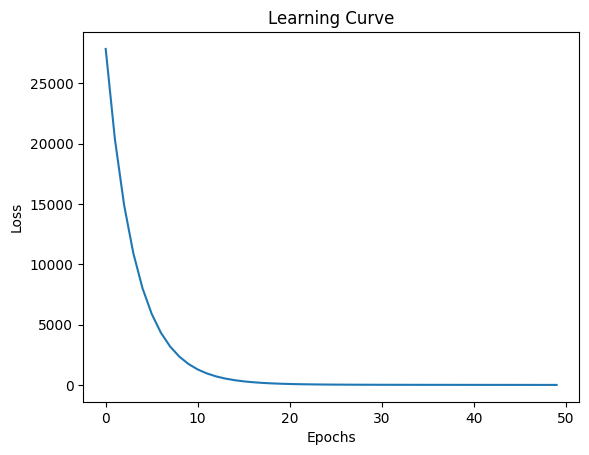

In [377]:
plt.plot(list(range(epochs)), errors)
plt.xlabel('Epochs')
plt.ylabel("Loss")
plt.title("Learning Curve")
plt.show()


In [378]:
def predict(X, params):

  M = np.dot(X, params['W'])

  P = M + params['B']

  return P


In [379]:
prediction = predict(X, params)


In [380]:
prediction


array([[-1.36236834],
       [ 3.05946166],
       [ 0.86955069],
       [ 7.79743987]])

In [381]:
Y


array([[2],
       [5],
       [6],
       [3]])

In [382]:
Y.shape


(4, 1)

In [383]:
X


array([[ 2,  3, -2],
       [ 4,  5, -1],
       [-5,  2,  3],
       [ 0,  5,  4]])